In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import json

import warnings
warnings.filterwarnings('ignore')

/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the Data
project_root = Path("/Users/nisith/Desktop/FYP/E2ETune-AI4DB/oltp_workloads")
benchmarks = ['smallbank', 'tpcc', 'twitter', 'wikipedia', 'ycsb']

data = []

for benchmark in benchmarks:
    folder_path = project_root / benchmark
    if not folder_path.exists():
        continue
        
    for xml_file in folder_path.glob("*.xml"):
        with open(xml_file, 'r') as f:
            content = f.read()
            
        weight_match = re.search(r'<weights>(.*?)</weights>', content)
        if weight_match:
            weights_str = weight_match.group(1)
            weights = [float(x) for x in weights_str.split(',')]
            
            # Pad weights to length 6 (since smallbank/ycsb have 6, others have 5)
            while len(weights) < 6:
                weights.append(0.0)
            
            data.append({
                'benchmark': benchmark,
                'filename': xml_file.name,
                'weights': weights
            })

df = pd.DataFrame(data)
print(f"Loaded {len(df)} workload configurations")

Loaded 1005 workload configurations



--- Benchmark: smallbank ---
Best params: {'n_neighbors': 15, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 3, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.843 | Davies-Bouldin: 0.204 | Calinski-Harabasz: 2010.5

Cluster distributions:
  Cluster 0: 8 files
  Cluster 1: 28 files
  Cluster 2: 37 files
  Cluster 3: 69 files
  Cluster 4: 40 files
  Cluster 5: 19 files


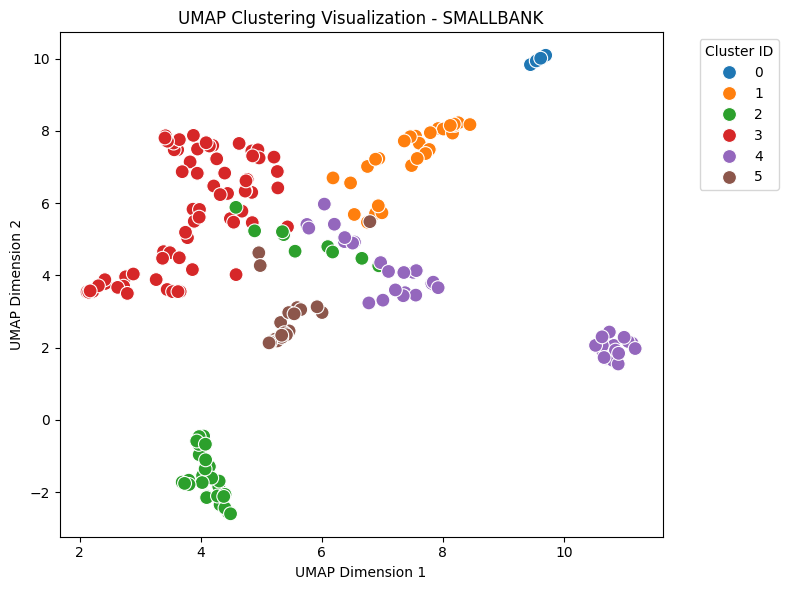


--- Benchmark: tpcc ---
Best params: {'n_neighbors': 15, 'min_dist': 0.1, 'umap_metric': 'cosine', 'min_cluster_size': 10, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.787 | Davies-Bouldin: 0.291 | Calinski-Harabasz: 1399.5

Cluster distributions:
  Cluster 0: 41 files
  Cluster 1: 44 files
  Cluster 2: 38 files
  Cluster 3: 78 files


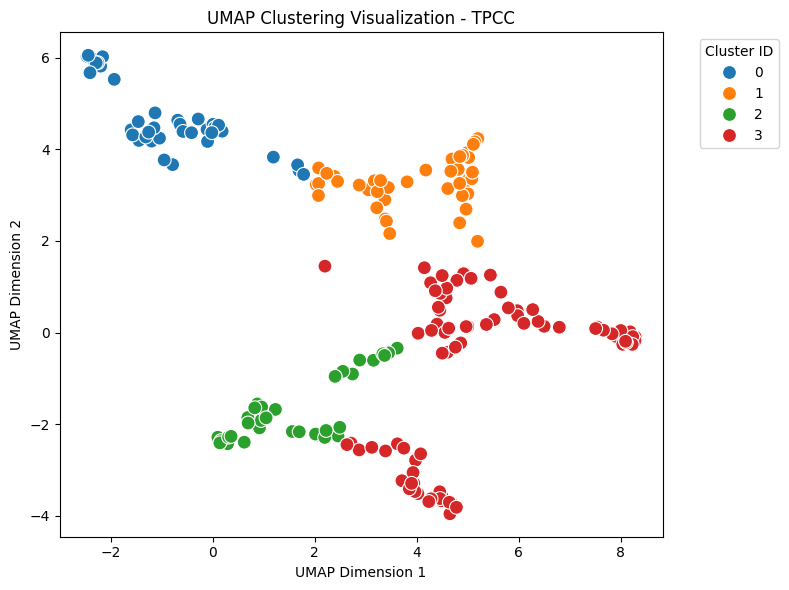


--- Benchmark: twitter ---
Best params: {'n_neighbors': 10, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 3, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.735 | Davies-Bouldin: 0.381 | Calinski-Harabasz: 1992.5

Cluster distributions:
  Cluster -1: 10 files
  Cluster 0: 37 files
  Cluster 1: 32 files
  Cluster 2: 10 files
  Cluster 3: 11 files
  Cluster 4: 15 files
  Cluster 5: 11 files
  Cluster 6: 13 files
  Cluster 7: 25 files
  Cluster 8: 10 files
  Cluster 9: 12 files
  Cluster 10: 15 files


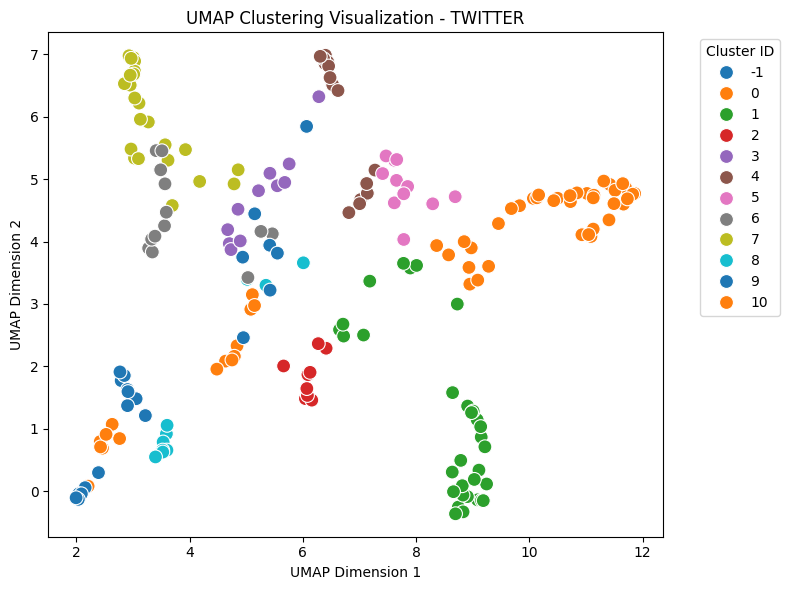


--- Benchmark: wikipedia ---
Best params: {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 10, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.835 | Davies-Bouldin: 0.244 | Calinski-Harabasz: 1553.0

Cluster distributions:
  Cluster -1: 5 files
  Cluster 0: 33 files
  Cluster 1: 39 files
  Cluster 2: 44 files
  Cluster 3: 25 files
  Cluster 4: 25 files
  Cluster 5: 30 files


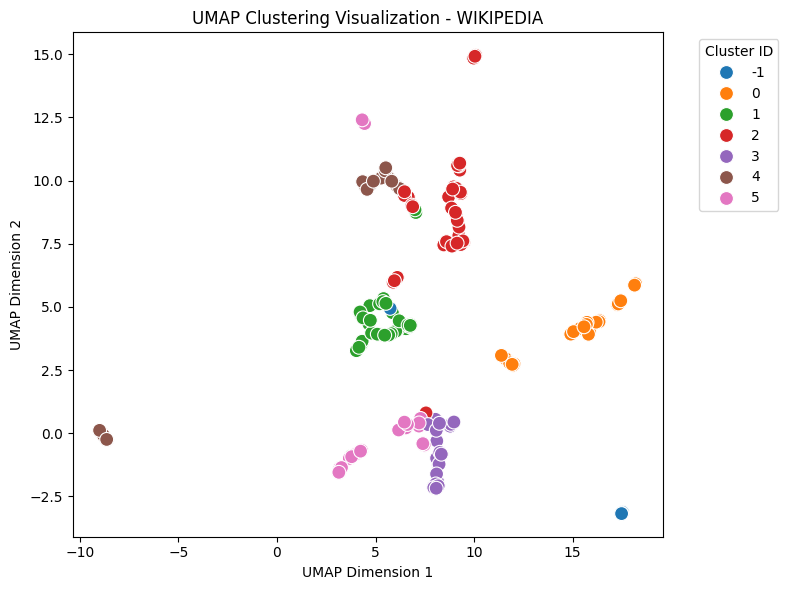


--- Benchmark: ycsb ---
Best params: {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'euclidean', 'min_cluster_size': 3, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.781 | Davies-Bouldin: 0.296 | Calinski-Harabasz: 2018.2

Cluster distributions:
  Cluster -1: 15 files
  Cluster 0: 11 files
  Cluster 1: 11 files
  Cluster 2: 9 files
  Cluster 3: 15 files
  Cluster 4: 14 files
  Cluster 5: 8 files
  Cluster 6: 16 files
  Cluster 7: 16 files
  Cluster 8: 15 files
  Cluster 9: 6 files
  Cluster 10: 11 files
  Cluster 11: 10 files
  Cluster 12: 11 files
  Cluster 13: 9 files
  Cluster 14: 8 files
  Cluster 15: 9 files
  Cluster 16: 7 files


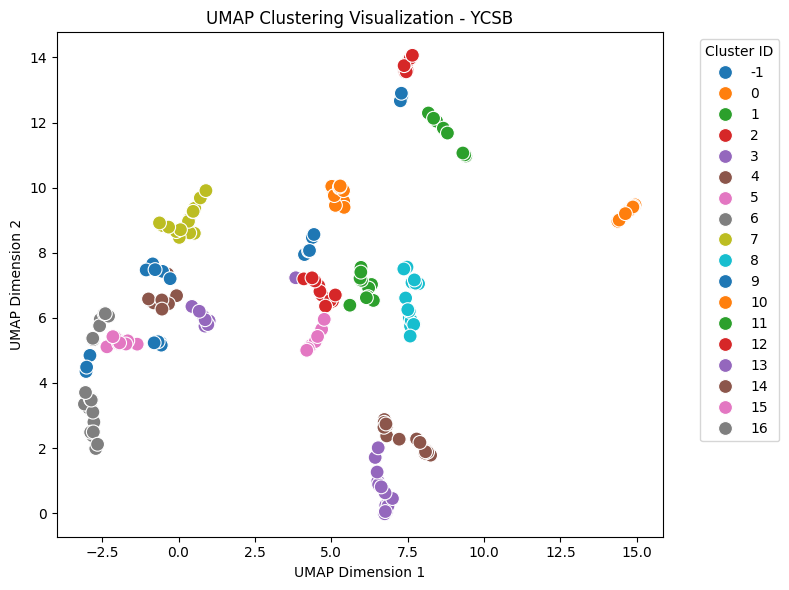


Total workloads clustered across benchmarks: 1005

Saved cluster assignments to /Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/oltp_clusters.json


In [3]:
# Per-Benchmark Clustering, Evaluation, and Visualization
results = []
cluster_output = {}

n_neighbors_list = [5, 10, 15]
min_dist_list = [0.0, 0.1]
umap_metrics = ['cosine', 'euclidean']
min_cluster_sizes = [3, 5, 10]
min_samples_list = [1, 5]
selection_methods = ['eom']

for benchmark in benchmarks:
    bench_cluster_dict = {}
    bench_df = df[df['benchmark'] == benchmark].copy()
    if len(bench_df) < 5:
        print(f"\n--- Benchmark: {benchmark} ---")
        print("Not enough data to cluster.")
        continue
        
    X_weights = np.array(bench_df['weights'].tolist())
    
    # Normalize weights
    scaler = StandardScaler()
    X = scaler.fit_transform(X_weights)
    
    best_score = -1
    best_result = None

    for nn in n_neighbors_list:
        if nn >= len(X):
            continue
        for md in min_dist_list:
            for um_metric in umap_metrics:
                reducer = umap.UMAP(
                    n_neighbors=nn, min_dist=md, metric=um_metric,
                    n_components=min(5, len(X)-2), random_state=42
                )
                try:
                    X_reduced = reducer.fit_transform(X)
                except Exception:
                    continue

                for mcs in min_cluster_sizes:
                    for ms in min_samples_list:
                        for sel in selection_methods:
                            clusterer = hdbscan.HDBSCAN(
                                min_cluster_size=mcs, min_samples=ms,
                                cluster_selection_method=sel, metric='euclidean'
                            )
                            try:
                                labels = clusterer.fit_predict(X_reduced)
                            except Exception:
                                continue

                            valid_mask = labels != -1
                            if np.sum(valid_mask) < 2 or len(set(labels[valid_mask])) < 2:
                                continue

                            try:
                                sil = silhouette_score(X_reduced[valid_mask], labels[valid_mask])
                            except Exception:
                                continue

                            if sil > best_score:
                                best_score = sil
                                db = davies_bouldin_score(X_reduced[valid_mask], labels[valid_mask])
                                ch = calinski_harabasz_score(X_reduced[valid_mask], labels[valid_mask])
                                best_result = {
                                    "X_reduced": X_reduced,
                                    "labels": labels,
                                    "sil": sil,
                                    "db": db,
                                    "ch": ch,
                                    "params": {
                                        "n_neighbors": nn, "min_dist": md, "umap_metric": um_metric,
                                        "min_cluster_size": mcs, "min_samples": ms, "selection": sel
                                    }
                                }
    
    print(f"\n{'='*40}\n--- Benchmark: {benchmark} ---\n{'='*40}")
    if best_result is None:
        print("Could not find valid clusters.")
        continue
        
    print("Best params:", best_result["params"])
    print(
        f"Metrics -> Silhouette: {best_result['sil']:.3f} | "
        f"Davies-Bouldin: {best_result['db']:.3f} | "
        f"Calinski-Harabasz: {best_result['ch']:.1f}"
    )
    
    bench_df['cluster_id'] = best_result['labels']
    
    print("\nCluster distributions:")
    for cluster_id, filenames in bench_df.groupby("cluster_id")["filename"]:
        print(f"  Cluster {cluster_id}: {len(filenames)} files")
        cluster_name = f"cluster_{cluster_id}"
        if cluster_id == -1:
            cluster_name = "noise"
        bench_cluster_dict[cluster_name] = filenames.tolist()
        
    cluster_output[benchmark] = bench_cluster_dict
        
    # Visualization: use UMAP 2D projection
    try:
        reducer_2d = umap.UMAP(n_components=2, n_neighbors=best_result['params']['n_neighbors'], random_state=42)
        X_2d = reducer_2d.fit_transform(X)
        
        bench_df['umap_1'] = X_2d[:, 0]
        bench_df['umap_2'] = X_2d[:, 1]
        
        # Plotting
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=bench_df, 
            x='umap_1', y='umap_2', 
            hue='cluster_id', 
            palette='tab10', 
            legend='full', 
            s=100
        )
        plt.title(f"UMAP Clustering Visualization - {benchmark.upper()}")
        plt.xlabel("UMAP Dimension 1")
        plt.ylabel("UMAP Dimension 2")
        plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Failed to generate visualization: {e}")
    
    results.append(bench_df)

if results:
    final_df = pd.concat(results, ignore_index=True)
    print(f"\nTotal workloads clustered across benchmarks: {len(final_df)}")

# Dump JSON outputs
out_json_path = "/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/oltp_clusters.json"
with open(out_json_path, 'w') as f:
    json.dump(cluster_output, f, indent=2)
print(f"\nSaved cluster assignments to {out_json_path}")